In [1]:
import sys
import os

sys.path.append(os.path.abspath("../.."))
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace
from src.config.llm import AgentConfig,GoogleLLm
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict

In [2]:
#first create the state
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [3]:
llm_config = GoogleLLm(model_name="gemini-2.5-flash-lite")
model = llm_config.llm



In [4]:
def generate_joke(state:JokeState):
    topic = state['topic']

    prompt = f"Generate a joke on the given topic: {topic}"

    joke = model.invoke(prompt).content

    return{'joke':joke}

In [5]:
def explain_joke(state:JokeState):
    joke =state['joke']
    prompt = f"Explain the give joke :{joke}"

    explaination = model.invoke(prompt).content
    return{'explanation':explaination}

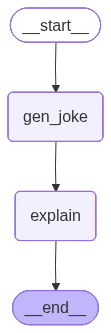

In [6]:
#initalize a graph 
graph = StateGraph(JokeState)

#add nodes

graph.add_node("gen_joke",generate_joke)
graph.add_node("explain",explain_joke)

#add the edges 

graph.add_edge(START,"gen_joke")
graph.add_edge("gen_joke","explain")
graph.add_edge("explain",END)

#compile the graph
checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [ ]:
initial_state = {
    'topic':'Pizza'
}
config_1 ={"configurable":{"thread_id":"1"}}
final_output = workflow.invoke(initial_state,config=config_1)
final_output

{'topic': 'AI',
 'joke': 'Why did the AI break up with the calculator?\n\nBecause it felt like the relationship was getting too **redundant**!',
 'explanation': 'This joke is a play on words, specifically on the word "**redundant**." Here\'s the breakdown:\n\n*   **AI (Artificial Intelligence):** A modern, advanced form of technology that can learn, process information, and often perform complex tasks.\n*   **Calculator:** A simpler, older piece of technology designed for basic arithmetic.\n*   **Redundant:** This word has two meanings that are relevant here:\n    1.  **Superfluous or unnecessary:** Something that is no longer needed because there\'s already something else doing the same job or a better job.\n    2.  **Repeating or saying the same thing over and over:** This relates to how a calculator performs calculations, which are often repetitive tasks.\n\n**The Joke\'s Logic:**\n\nThe AI, being a more advanced and capable entity, feels that its relationship with the calculator is

In [9]:
workflow.get_state(config_1)


StateSnapshot(values={'topic': 'AI', 'joke': 'Why did the AI break up with the calculator?\n\nBecause it felt like the relationship was getting too **redundant**!', 'explanation': 'This joke is a play on words, specifically on the word "**redundant**." Here\'s the breakdown:\n\n*   **AI (Artificial Intelligence):** A modern, advanced form of technology that can learn, process information, and often perform complex tasks.\n*   **Calculator:** A simpler, older piece of technology designed for basic arithmetic.\n*   **Redundant:** This word has two meanings that are relevant here:\n    1.  **Superfluous or unnecessary:** Something that is no longer needed because there\'s already something else doing the same job or a better job.\n    2.  **Repeating or saying the same thing over and over:** This relates to how a calculator performs calculations, which are often repetitive tasks.\n\n**The Joke\'s Logic:**\n\nThe AI, being a more advanced and capable entity, feels that its relationship wit